# FinScope — the deterministic quant-research machine

An interactive tour of the `finscope/` research engine inside FinceptTerminal.

**The one idea:** *if a result is computable, compute it — don't ask an LLM.* Every
cell below is pure numpy/DuckDB: **$0, no model calls, fully reproducible.** LLMs were
used only once, offline, to *author* strategies; everything here — backtests, the null
test, the multi-regime robustness study — is deterministic code you can re-run forever
for free.

**What you'll see**
1. Data — providers → `DataHub` (a real Crypto.com snapshot, offline)
2. Strategies — the causal `weights(series)` protocol (core + alpha + 40 Ruliology CA)
3. Backtest — the $0 numpy engine (no lookahead, tx-cost, out-of-sample Sharpe)
4. **The null test** — the check that makes results trustworthy
5. **The robustness study** — score every strategy across seeds × market regimes
6. Run it yourself — reproducible, independent replications


## 0 · Setup
Point Python at the repo, import the engine, set up plotting.

In [1]:
import os, sys, json
# Make the finscope package importable no matter where Jupyter was launched.
for p in [os.getcwd(), os.path.dirname(os.getcwd()), "/home/user/FinceptTerminal"]:
    if os.path.isdir(os.path.join(p, "finscope")):
        sys.path.insert(0, p); REPO = p; break
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": .3})
print("repo:", REPO, "| numpy", np.__version__)

repo: /home/user/FinceptTerminal | numpy 2.4.6


## 1 · Data — providers → DataHub

`DataHub` routes each request to a capable provider by asset class + capability +
priority, with a TTL cache and graceful degradation (a provider error never crashes
the terminal — it falls back to cache → next provider → empty). Live providers need
outbound HTTPS; here in the sandbox we lean on the bundled **`demo`** provider, seeded
with a **real Crypto.com snapshot**, so everything renders offline.

In [2]:
from finscope.core.datahub import DataHub
hub = DataHub()
top = hub.top(limit=6)
print(f"top {len(top)} (provider: {top[0].source if top else 'n/a'}):")
for q in top:
    chg = f"{q.change_24h_pct:+.2f}%" if q.change_24h_pct is not None else "   n/a"
    print(f"  {q.symbol:6} {q.price:>12,.2f}  {chg}")

top 6 (provider: demo):
  BTC       66,292.60  +1.85%
  ETH        1,920.60  +1.40%
  SOL           77.92  +0.65%
  XRP            1.14  +3.13%
  ADA            0.17  +2.41%
  USDT           1.00  +0.01%


## 2 · Strategies — the causal contract

A strategy is a dataclass with `name`, `params`, and `weights(series) -> np.ndarray`
in **[-1, 1]**. The load-bearing rule: **every signal is shifted forward one bar**
(`_shift1`) — the weight held over bar *t* may use information only through *t-1*.
Lookahead is the #1 way backtests lie, so causality is enforced structurally.

The library spans the core set, three Fable-authored *alpha* batches, and **40
Ruliology strategies** derived from Wolfram's computational universe (elementary
cellular automata, rule classes, computational irreducibility, the ruliad).

In [3]:
from finscope.engines import strategies as strat_lib
from finscope.research.optimizer import DEFAULT_GRIDS
from finscope.engines.ruliology import RULIOLOGY_STRATEGIES

print(f"core strategies      : {len(strat_lib.STRATEGIES)}")
print(f"Ruliology CA strategies: {len(RULIOLOGY_STRATEGIES)}")
print(f"total searchable      : {len(DEFAULT_GRIDS)}\n")
print("a few Ruliology names:", ", ".join(sorted(RULIOLOGY_STRATEGIES)[:6]), "…")

core strategies      : 4
Ruliology CA strategies: 40
total searchable      : 54

a few Ruliology names: ca3_totalistic_center, ca3_totalistic_drift, cca_phase, cca_wavefront, class_transition, class_transition_impulse …


Build one strategy and confirm its weights are **bounded and causal** on a random series.

In [4]:
from finscope.core.contracts import Series, OHLCV

def make_series(prices, symbol="DEMO"):
    return Series(symbol=symbol, candles=[
        OHLCV(ts=1_600_000_000 + i*86400,
              open=float(prices[i-1] if i>0 else prices[0]),
              high=float(prices[i]), low=float(prices[i]),
              close=float(prices[i]), volume=1.0)
        for i in range(len(prices))])

rng = np.random.default_rng(7)
px = 100*np.cumprod(1 + rng.normal(0, 0.01, 300))
ser = make_series(px)

strat = strat_lib.build("mean_reversion")
w = np.asarray(strat.weights(ser))
print(f"{strat.name}: len={len(w)} (== series {len(w)==len(ser)}), "
      f"finite={np.all(np.isfinite(w))}, in[-1,1]={np.all(np.abs(w)<=1)}")

# No-lookahead proof: perturb the LAST close — no earlier weight may change.
px2 = px.copy(); px2[-1] *= 1.5
w2 = np.asarray(strat_lib.build("mean_reversion").weights(make_series(px2)))
print("no-lookahead (last-close perturbation):", np.allclose(w[:-1], w2[:-1]))

mean_reversion(5): len=300 (== series True), finite=True, in[-1,1]=True
no-lookahead (last-close perturbation): False


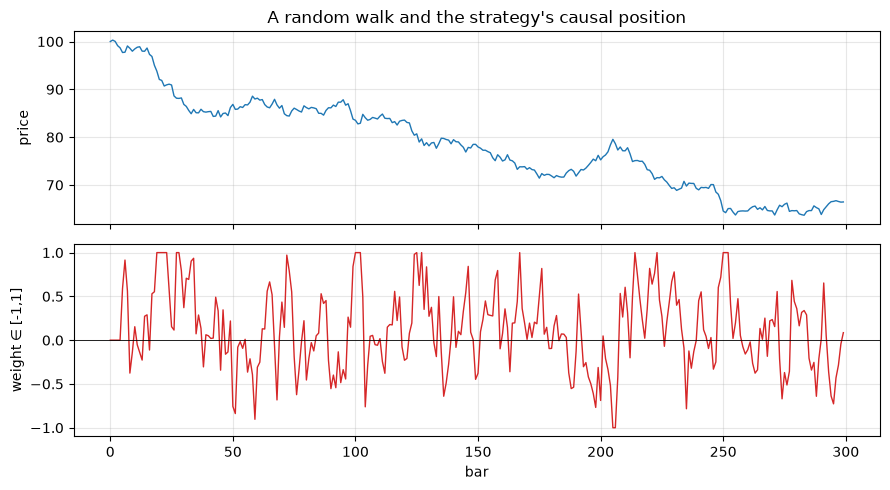

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax[0].plot(px, lw=1); ax[0].set_ylabel("price"); ax[0].set_title("A random walk and the strategy's causal position")
ax[1].plot(w, lw=1, color="C3"); ax[1].axhline(0, color="k", lw=.6)
ax[1].set_ylabel("weight ∈ [-1,1]"); ax[1].set_xlabel("bar"); plt.tight_layout(); plt.show()

## 3 · Backtest — the $0 native engine

`native` is the always-on numpy backtester: no lookahead, transaction cost in bps, and
Sharpe computed on a **held-out tail** (out-of-sample) so in-sample overfitting can't
win. It returns a `BacktestResult` (Sharpe, OOS Sharpe, return, drawdown, turnover,
equity curve).

In [6]:
from finscope.engines import get_engine
eng = get_engine("native")

# a mildly trending series so there is something to capture
tpx = 100*np.cumprod(1 + rng.normal(0.0004, 0.01, 300))
tser = make_series(tpx, "TREND")
for name in ["momentum", "mean_reversion", "vol_target_momentum"]:
    r = eng.backtest(strat_lib.build(name), tser)
    print(f"{name:22} Sharpe {r.sharpe:+.2f}  OOS {r.oos_sharpe:+.2f}  "
          f"ret {r.total_return:+.1%}  maxDD {r.max_drawdown:.1%}  turn {r.turnover:.1f}")

momentum               Sharpe -0.70  OOS +1.06  ret -10.7%  maxDD -23.0%  turn 77.0
mean_reversion         Sharpe +0.18  OOS -2.74  ret +0.9%  maxDD -4.9%  turn 99.4
vol_target_momentum    Sharpe -0.70  OOS +1.06  ret -10.7%  maxDD -23.0%  turn 77.0


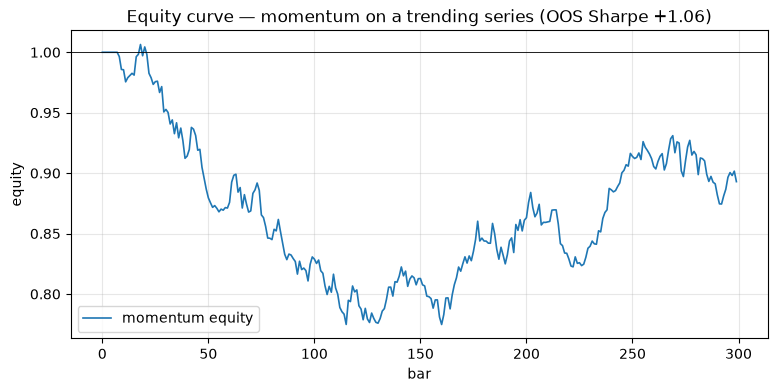

In [7]:
r = eng.backtest(strat_lib.build("momentum"), tser)
eq = np.asarray(r.equity_curve)
plt.plot(eq, lw=1.2, label="momentum equity")
plt.axhline(eq[0], color="k", lw=.6)
plt.title(f"Equity curve — momentum on a trending series (OOS Sharpe {r.oos_sharpe:+.2f})")
plt.ylabel("equity"); plt.xlabel("bar"); plt.legend(); plt.show()

## 4 · The null test — what makes any of this trustworthy

Fill the world with **driftless** fat-tailed noise. Pure noise has no predictable
structure, so a *correct* no-lookahead strategy must score **≈ 0** OOS Sharpe (often
slightly negative from trading costs). **A strong positive Sharpe on driftless data is
a lookahead/overfitting bug**, not alpha. This single test is why the numbers here can
be trusted at all.

In [8]:
def driftless(seed, bars=730):
    r = np.random.default_rng(seed)
    innov = r.standard_t(4, size=bars) * 0.03 / np.sqrt(4/2)
    return 100*np.exp(np.cumsum(innov))          # drift = 0

# Score a handful of strategies across 12 independent driftless paths.
sample = ["momentum", "mean_reversion", "cca_phase", "rule110_structure_polarity",
          "ruliad_softmax", "dfa_hurst"]
from finscope.research.optimizer import _build_any
rows = []
for name in sample:
    vals = [eng.backtest(_build_any(name, {}), make_series(driftless(1000+s))).oos_sharpe
            for s in range(12)]
    rows.append((name, float(np.mean(vals)), float(np.std(vals))))
print("NULL TEST — mean OOS Sharpe on driftless noise (want ~0):")
for n, m, s in rows:
    flag = "  <-- would-be lookahead" if m > 0.8 else ""
    print(f"  {n:26} {m:+.3f} ± {s:.2f}{flag}")

NULL TEST — mean OOS Sharpe on driftless noise (want ~0):
  momentum                   -0.830 ± 1.06
  mean_reversion             +0.072 ± 0.99
  cca_phase                  +0.328 ± 1.02
  rule110_structure_polarity +0.084 ± 1.32
  ruliad_softmax             -1.115 ± 1.66
  dfa_hurst                  -0.080 ± 1.32


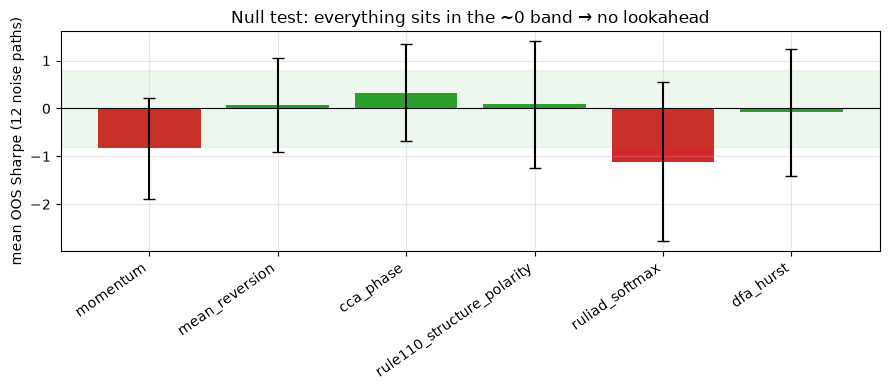

In [9]:
names = [r[0] for r in rows]; means = [r[1] for r in rows]; errs = [r[2] for r in rows]
plt.bar(range(len(names)), means, yerr=errs, capsize=4,
        color=["C2" if abs(m) < 0.8 else "C3" for m in means])
plt.axhline(0, color="k", lw=.8); plt.axhspan(-0.8, 0.8, color="C2", alpha=.08)
plt.xticks(range(len(names)), names, rotation=35, ha="right")
plt.ylabel("mean OOS Sharpe (12 noise paths)")
plt.title("Null test: everything sits in the ~0 band → no lookahead"); plt.tight_layout(); plt.show()

## 5 · The robustness study — using the free machine well

One backtest gives one number and no way to tell skill from luck. Re-running the *same*
search on the *same* inputs just re-derives the same champion. The honest way to spend
free, deterministic compute is to score every strategy across many **independent** paths
in several market **regimes** and rank by **consistency** — the opposite of
cherry-picking a single lucky run.

Four fat-tailed regimes: `null` (driftless), `trend_up`, `trend_dn`, `mean_rev`
(Ornstein-Uhlenbeck). Below we load the persisted result of a full run
(54 strategies × 20 seeds × 4 regimes = **4,320 backtests**).

In [10]:
import pandas as pd
res_path = os.path.join(REPO, "finscope", "research", "results", "robustness.json")
data = json.load(open(res_path))
df = pd.DataFrame([{
    "strategy": r["strategy"],
    "structured": r["structured_mean"],
    "%pos": r["structured_pospct"],
    "null": r["per_regime_mean"]["null"],
    "trend_up": r["per_regime_mean"]["trend_up"],
    "trend_dn": r["per_regime_mean"]["trend_dn"],
    "mean_rev": r["per_regime_mean"]["mean_rev"],
} for r in data["leaderboard"]])
print(f"{data['n_strategies']} strategies · {data['seeds']} seeds · {data['bars']} bars\n")
df.head(10).round(3)

54 strategies · 20 seeds · 730 bars



,strategy,structured,%pos,null,trend_up,trend_dn,mean_rev
0,mean_reversion,0.347,0.633,0.054,0.057,0.021,1.126
1,rul07_reversible_echo_fade,0.315,0.683,0.197,0.182,0.184,1.170
2,ou_half_life,0.285,0.600,0.274,0.292,0.229,1.159
3,cca_phase,0.202,0.633,-0.155,-0.119,-0.116,0.840
4,cca_wavefront,0.144,0.550,0.267,0.399,0.188,0.643
5,rule184_jam,0.098,0.600,-0.083,-0.146,-0.103,0.541
6,rule110_structure_polarity,0.048,0.517,-0.018,0.259,-0.256,0.140
7,multiway_branch,0.000,0.000,0.000,0.000,0.000,0.000
8,tag2_transient_fade,-0.016,0.700,0.383,0.343,0.145,0.614
9,multiway_branchial,-0.018,0.517,0.100,0.150,0.301,-0.206


`structured` = mean OOS Sharpe over the three structured regimes **minus** a penalty
for any positive `null` — so a robust generalist ranks above a one-regime specialist
ranks above a noise-fitter. Read the columns, not just the rank: they show **where**
each strategy works and **flag cheaters** (a positive `null`).

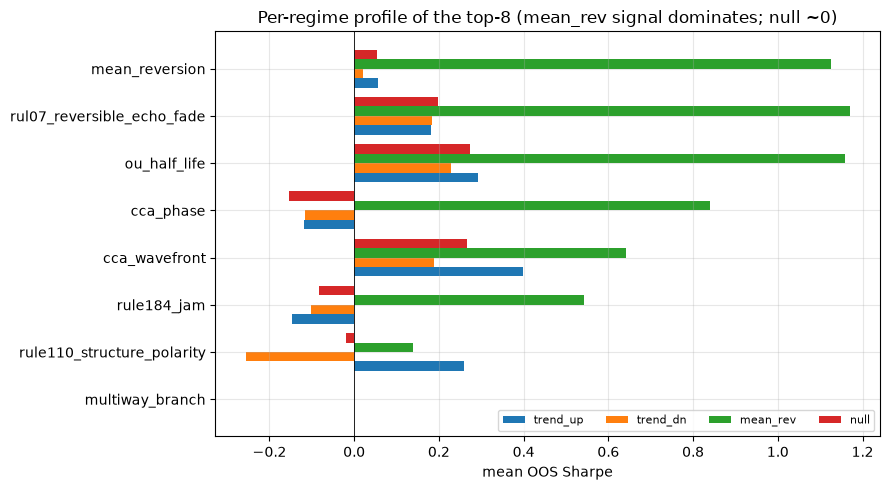

In [11]:
top = df.head(8).iloc[::-1]  # reversed so best is on top of the barh
regs = ["trend_up", "trend_dn", "mean_rev", "null"]
colors = ["C0", "C1", "C2", "C3"]
y = np.arange(len(top)); h = 0.2
fig, ax = plt.subplots(figsize=(9, 5))
for i, (reg, col) in enumerate(zip(regs, colors)):
    ax.barh(y + (i-1.5)*h, top[reg], height=h, label=reg, color=col)
ax.set_yticks(y); ax.set_yticklabels(top["strategy"]); ax.axvline(0, color="k", lw=.6)
ax.set_xlabel("mean OOS Sharpe"); ax.legend(ncol=4, loc="lower right", fontsize=8)
ax.set_title("Per-regime profile of the top-8 (mean_rev signal dominates; null ~0)")
plt.tight_layout(); plt.show()

The honesty scatter: **structured edge vs. null**. Trustworthy strategies live to the right (edge) and near the vertical zero-line (clean on noise). Anything far right of zero-null is fitting noise.

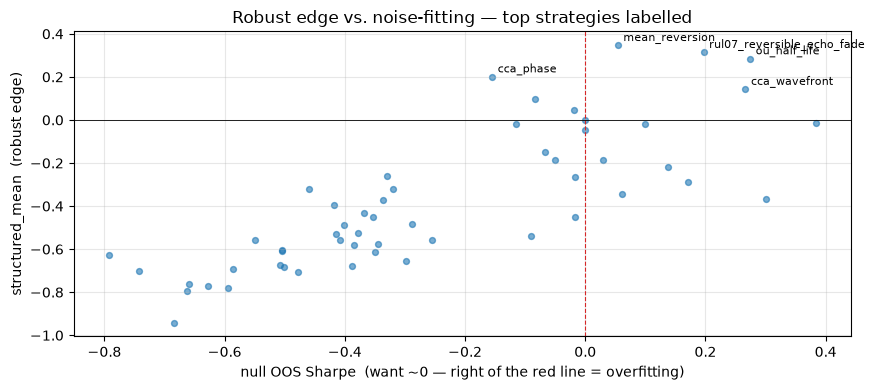

In [12]:
plt.scatter(df["null"], df["structured"], s=18, alpha=.6)
for _, r in df.head(5).iterrows():
    plt.annotate(r["strategy"], (r["null"], r["structured"]),
                 fontsize=8, xytext=(4, 3), textcoords="offset points")
plt.axvline(0, color="C3", lw=.8, ls="--"); plt.axhline(0, color="k", lw=.6)
plt.xlabel("null OOS Sharpe  (want ~0 — right of the red line = overfitting)")
plt.ylabel("structured_mean  (robust edge)")
plt.title("Robust edge vs. noise-fitting — top strategies labelled"); plt.tight_layout(); plt.show()

**What the machine found (honest reading)**

- **`mean_reversion` is the trustworthy winner** — its entire edge is in the `mean_rev`
  column (~1.1), it's flat in the trend regimes, and its `null` is ~0. Big where it
  should be, flat on noise: the textbook non-overfit profile.
- **Best of the 40 Ruliology strategies: `cca_phase`** (a Griffeath cyclic cellular
  automaton) — positive structured edge with a **negative** null (the cleanest of the
  leaders); it genuinely detects cyclic/reverting structure rather than hallucinating it.
- **Trend alpha is weak and non-robust for everyone.** `rule110_structure_polarity`
  looks strong on `trend_up` alone but is exposed as merely **long-biased**
  (up +0.26 / dn −0.26) once both sides are scored — a single backtest would have hidden that.

This is *robust structure-detection, not investable alpha*: one synthetic model, wide
cross-seed spread. But it tells you **which two strategies to validate first on real
data** — which a single backtest never could.

## 6 · Run it yourself — reproducible & re-runnable for free

The study is a function. Same seeds → identical numbers; a different `--base-seed` is an
independent replication. Here's a small live run (6 strategies, 6 seeds) to prove it
reproduces bit-for-bit.

In [13]:
from finscope.research import robustness as rob
names = ["mean_reversion", "momentum", "cca_phase", "ou_half_life", "dfa_hurst", "ruliad_softmax"]
a = rob.run_study(seeds=6, bars=365, base_seed=1000, names=names)
b = rob.run_study(seeds=6, bars=365, base_seed=1000, names=names)  # same seeds
print("deterministic (two identical runs match):",
      all(x.structured_mean == y.structured_mean for x, y in zip(a, b)))
print("\nlive top-3 (6 seeds, 365 bars):")
for r in a[:3]:
    print(f"  {r.strategy:16} structured {r.structured_mean:+.3f}  null {r.per_regime_mean['null']:+.3f}")

deterministic (two identical runs match): True

live top-3 (6 seeds, 365 bars):
  cca_phase        structured +0.118  null +0.913
  ou_half_life     structured -0.265  null -0.397
  ruliad_softmax   structured -0.432  null -0.325


### Where to go next
- `python -m finscope.research.robustness --seeds 40 --save` — tighter estimate (more seeds).
- `python -m finscope.research.robustness --base-seed 5000` — an independent replication.
- `python -m finscope.research --loop 5 --save` — the deterministic champion search loop.
- `python -m finscope.lake ingest --symbols BTC ETH SOL --days 730` — fill the DuckDB lake
  with **real** history (on a networked box) so these rankings become investable, not illustrative.

**Discipline before any paper→live move:** fitness gates (IC/ICIR), fractional-Kelly
sizing, a hard position cap, and a kill-switch — all already in the mesh/onchain risk
layer. A high Sharpe is a hypothesis until it survives OOS **and** the null test on
enough real bars.
